In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
import statistics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from scipy import stats


In [3]:
#verify it's the correct 

'''
How to fix it
Option 1: Edit the notebook metadata directly

Change this:

"kernelspec": {
  "display_name": "Python 3",
  "language": "python",
  "name": "python3"
}

to:

"kernelspec": {
  "display_name": "Python (Anaconda)",
  "language": "python",
  "name": "anaconda"
}
Then save the notebook, close it, reopen it, and run:

import sys
print(sys.executable)

You want to see:

/opt/anaconda3/bin/python
'''

import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [56]:
subs_ads = pd.read_csv('data/subscribers_joined.csv')

In [57]:
subs_ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subscriber_id        3000 non-null   object 
 1   signup_date          3000 non-null   object 
 2   plan                 3000 non-null   object 
 3   country              3000 non-null   object 
 4   acquisition_channel  3000 non-null   object 
 5   campaign_id          3000 non-null   object 
 6   campaign_start_date  3000 non-null   object 
 7   campaign_end_date    3000 non-null   object 
 8   primary_device       3000 non-null   object 
 9   age                  3000 non-null   int64  
 10  signup_show          3000 non-null   object 
 11  show_genre           3000 non-null   object 
 12  lifecycle_stage      3000 non-null   object 
 13  churn_date           355 non-null    object 
 14  monthly_spend_usd    3000 non-null   float64
 15  is_bundled           3000 non-null   b

In [58]:
# Fill missing values
subs_ads['avg_roas'] = subs_ads['avg_roas'].fillna(subs_ads['avg_roas'].median())

# Convert boolean columns to int
subs_ads['is_bundled'] = subs_ads['is_bundled'].astype(int)

# Define features — no encoding needed, all numeric
features = [
    'total_spend',
    'plan_price',
    'avg_roas',
    'age',
    'is_bundled'
]

# X = inputs | y = what we are predicting
X = subs_ads[features]
y = subs_ads['total_signups']

print("Features:", features)
print("Target: total_signups")
print(f"X shape: {X.shape} | y shape: {y.shape}")
print(f"\nTarget range: {y.min()} – {y.max()} | Mean: {y.mean():.2f}")

Features: ['total_spend', 'plan_price', 'avg_roas', 'age', 'is_bundled']
Target: total_signups
X shape: (3000, 5) | y shape: (3000,)

Target range: 14 – 75 | Mean: 33.53


In [60]:
# Split into training (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [61]:
# Evaluate
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared: {r2:.3f}")
print(f"RMSE:      {rmse:.2f} signups")

# Feature importance
importance = pd.DataFrame({
    'feature':     features,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Importance:")
print(importance.to_string(index=False))

R-squared: 0.958
RMSE:      2.98 signups

Feature Importance:
    feature  coefficient
   avg_roas   287.338786
 is_bundled     0.019981
        age     0.002375
total_spend     0.000893
 plan_price    -0.000453


In [62]:
# ── CORRELATION ──────────────────────────────────────────
corr_cols = ['total_spend', 'plan_price', 'avg_roas', 'age', 'is_bundled', 'total_signups']

correlation = subs_ads[corr_cols].corr()
print("Correlation with total_signups:")
print(correlation['total_signups'].sort_values(ascending=False).to_string())

Correlation with total_signups:
total_signups    1.000000
total_spend      0.837152
avg_roas         0.223036
plan_price       0.010235
age              0.005604
is_bundled      -0.054480


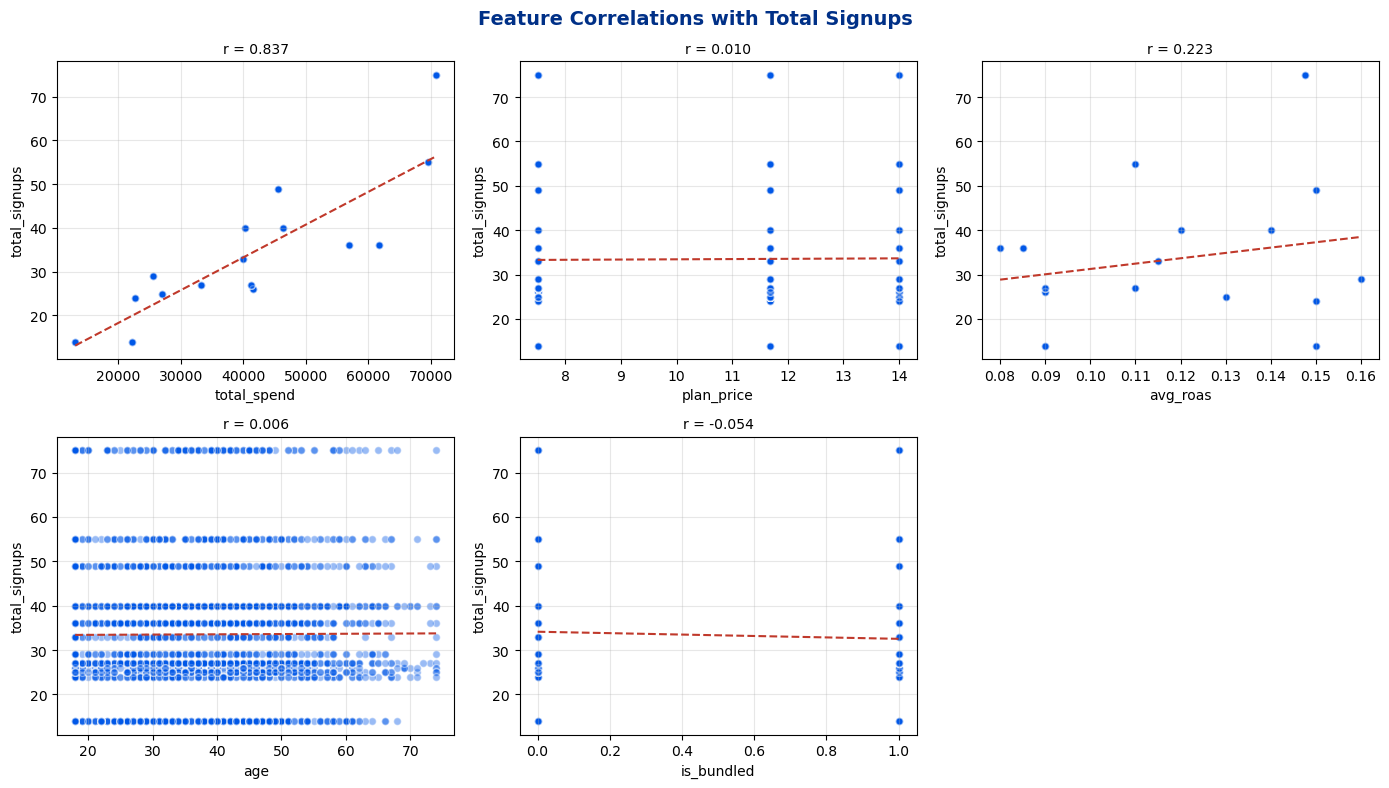

Saved: scatter_plots.png


In [63]:
# ── SCATTER PLOTS ────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Correlations with Total Signups', 
             fontsize=14, fontweight='bold', color='#003087')

features_plot = ['total_spend', 'plan_price', 'avg_roas', 'age', 'is_bundled']

for i, feat in enumerate(features_plot):
    row = i // 3
    col = i % 3
    ax  = axes[row][col]
    
    ax.scatter(subs_ads[feat], subs_ads['total_signups'],
               alpha=0.4, color='#0057E7', edgecolors='white', s=30)
    
    # Add trend line
    z = np.polyfit(subs_ads[feat], subs_ads['total_signups'], 1)
    p = np.poly1d(z)
    ax.plot(sorted(subs_ads[feat]), p(sorted(subs_ads[feat])),
            color='#C0392B', linewidth=1.5, linestyle='--')
    
    corr_val = subs_ads[feat].corr(subs_ads['total_signups'])
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('total_signups', fontsize=10)
    ax.set_title(f'r = {corr_val:.3f}', fontsize=10)
    ax.grid(True, alpha=0.3)

# Hide the empty 6th subplot
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scatter_plots.png")